In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.duplicated().sum()

np.int64(0)

# **Step 7 — Fix the dates**

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# **Step 8 — Find the date range**

In [10]:
print("First Order Date:", df['Order Date'].min())
print("Last Order Date:", df['Order Date'].max())

First Order Date: 2014-01-03 00:00:00
Last Order Date: 2017-12-30 00:00:00


# **Step 9 — See how much you sold each year**

In [11]:
df['Year'] = df['Order Date'].dt.year

yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales

,Sales
Year,
2014,484247.4981
2015,470532.5090
2016,609205.5980
2017,733215.2552


# **Step 10 — Make your first graph 📈**

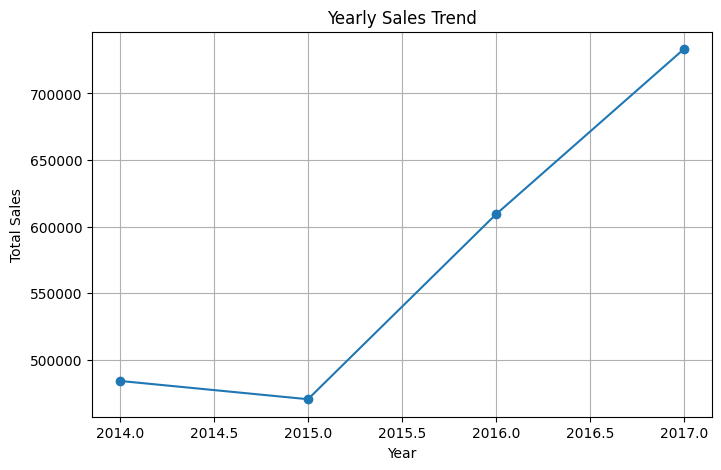

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(yearly_sales.index, yearly_sales.values, marker='o')

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.grid(True)
plt.show()

# **Step 11: Monthly Sales**

In [13]:
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales

,Sales
Month,
1,94924.8356
2,59751.2514
3,205005.4888
4,137762.1286
5,155028.8117
6,152718.6793
7,147238.0970
8,159044.0630
9,307649.9457


# **Step 12 — Make the monthly sales graph**

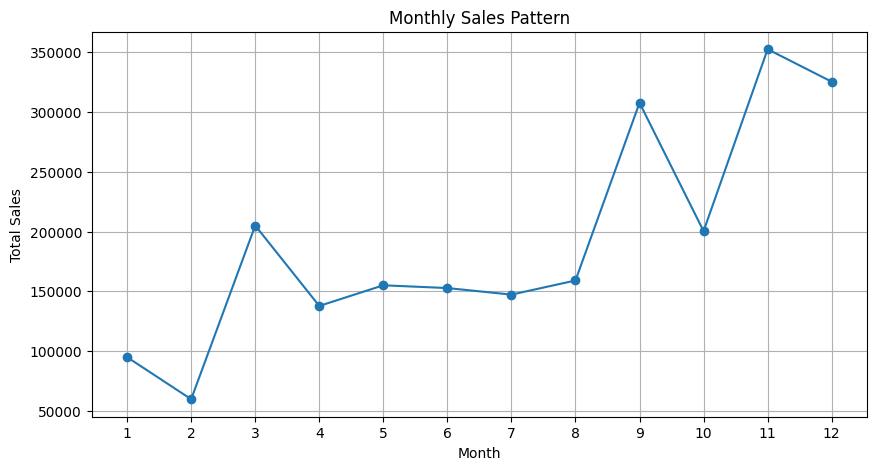

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Pattern')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

# **Step 13 — Now we're going to make the REAL forecasting dataset**

In [15]:
monthly_sales_ts = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales_ts

,Sales
Order Date,
2014-01,14236.8950
2014-02,4519.8920
2014-03,55691.0090
2014-04,28295.3450
2014-05,23648.2870
2014-06,34595.1276
2014-07,33946.3930
2014-08,27909.4685
2014-09,81777.3508


In [16]:
print(monthly_sales_ts.head())
print(monthly_sales_ts.tail())

Order Date
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64
Order Date
2017-08     63120.8880
2017-09     87866.6520
2017-10     77776.9232
2017-11    118447.8250
2017-12     83829.3188
Freq: M, Name: Sales, dtype: float64


# **Step 14 — Visualize the 48 months**

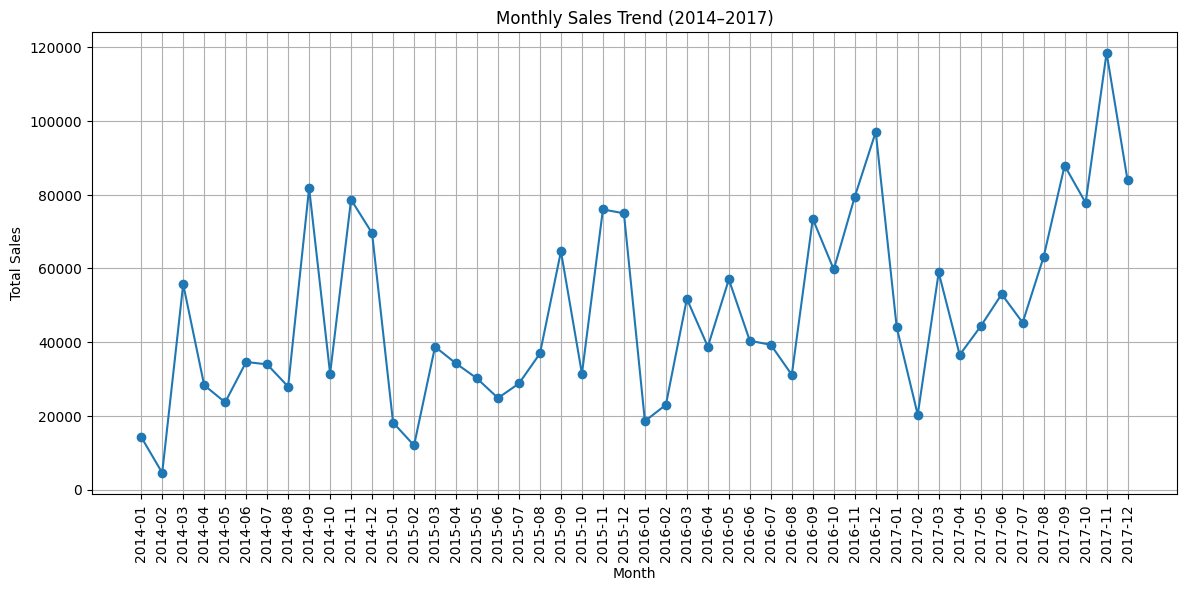

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales_ts.index.astype(str),
    monthly_sales_ts.values,
    marker='o'
)

plt.title('Monthly Sales Trend (2014–2017)')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=90)
plt.grid(True)

plt.show()

# **Step 15 — Now we prepare for Machine Learning**

In [18]:
forecast_df = monthly_sales_ts.reset_index()

forecast_df.columns = ['Order Date', 'Sales']

forecast_df.head()

,Order Date,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


# **Step 16 — Create Lag Features**

In [19]:
forecast_df['Lag_1'] = forecast_df['Sales'].shift(1)
forecast_df['Lag_2'] = forecast_df['Sales'].shift(2)
forecast_df['Lag_3'] = forecast_df['Sales'].shift(3)

forecast_df.head(10)

,Order Date,Sales,Lag_1,Lag_2,Lag_3
0,2014-01,14236.8950,NaN,NaN,NaN
1,2014-02,4519.8920,14236.8950,NaN,NaN
2,2014-03,55691.0090,4519.8920,14236.8950,NaN
3,2014-04,28295.3450,55691.0090,4519.8920,14236.8950
4,2014-05,23648.2870,28295.3450,55691.0090,4519.8920
5,2014-06,34595.1276,23648.2870,28295.3450,55691.0090
6,2014-07,33946.3930,34595.1276,23648.2870,28295.3450
7,2014-08,27909.4685,33946.3930,34595.1276,23648.2870
8,2014-09,81777.3508,27909.4685,33946.3930,34595.1276
9,2014-10,31453.3930,81777.3508,27909.4685,33946.3930


# **Step 17 — Add Month and Year**

In [20]:
forecast_df['Month'] = forecast_df['Order Date'].dt.month
forecast_df['Year'] = forecast_df['Order Date'].dt.year

forecast_df.head(10)

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Month,Year
0,2014-01,14236.8950,NaN,NaN,NaN,1,2014
1,2014-02,4519.8920,14236.8950,NaN,NaN,2,2014
2,2014-03,55691.0090,4519.8920,14236.8950,NaN,3,2014
3,2014-04,28295.3450,55691.0090,4519.8920,14236.8950,4,2014
4,2014-05,23648.2870,28295.3450,55691.0090,4519.8920,5,2014
5,2014-06,34595.1276,23648.2870,28295.3450,55691.0090,6,2014
6,2014-07,33946.3930,34595.1276,23648.2870,28295.3450,7,2014
7,2014-08,27909.4685,33946.3930,34595.1276,23648.2870,8,2014
8,2014-09,81777.3508,27909.4685,33946.3930,34595.1276,9,2014
9,2014-10,31453.3930,81777.3508,27909.4685,33946.3930,10,2014


# **Step 18 — Remove the NaN rows**

In [21]:
forecast_df = forecast_df.dropna()

forecast_df = forecast_df.reset_index(drop=True)

forecast_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Month,Year
0,2014-04,28295.3450,55691.0090,4519.8920,14236.895,4,2014
1,2014-05,23648.2870,28295.3450,55691.0090,4519.892,5,2014
2,2014-06,34595.1276,23648.2870,28295.3450,55691.009,6,2014
3,2014-07,33946.3930,34595.1276,23648.2870,28295.345,7,2014
4,2014-08,27909.4685,33946.3930,34595.1276,23648.287,8,2014


In [22]:
forecast_df.shape

(45, 7)

# **Step 19 — Train/Test Split**

**19A — Create X and y**

In [23]:
X = forecast_df[['Lag_1', 'Lag_2', 'Lag_3', 'Month', 'Year']]
y = forecast_df['Sales']

**19B — Split the timeline**

In [24]:
split_index = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 36
Testing rows: 9


# **Step 20 — Train Linear Regression**

In [25]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)


LinearRegression()

In [26]:
y_pred_lr = model_lr.predict(X_test)

y_pred_lr

array([42776.77636342, 47548.76669264, 56040.87527026, 58530.15397179,
       65230.81239863, 70254.32274958, 73713.67798341, 82032.79901098,
       87511.16801299])

# **Step 21 — See Actual vs Predicted**

In [27]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred_lr
})

comparison

,Actual Sales,Predicted Sales
0,36521.5361,42776.776363
1,44261.1102,47548.766693
2,52981.7257,56040.875270
3,45264.4160,58530.153972
4,63120.8880,65230.812399
5,87866.6520,70254.322750
6,77776.9232,73713.677983
7,118447.8250,82032.799011
8,83829.3188,87511.168013


# **Step 22 — Calculate MAE, RMSE and R²**

In [28]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 9972.239818419584
RMSE: 14552.742894145813
R²  : 0.6600058026008291


# **Step 23 — Make an Actual vs Predicted graph**

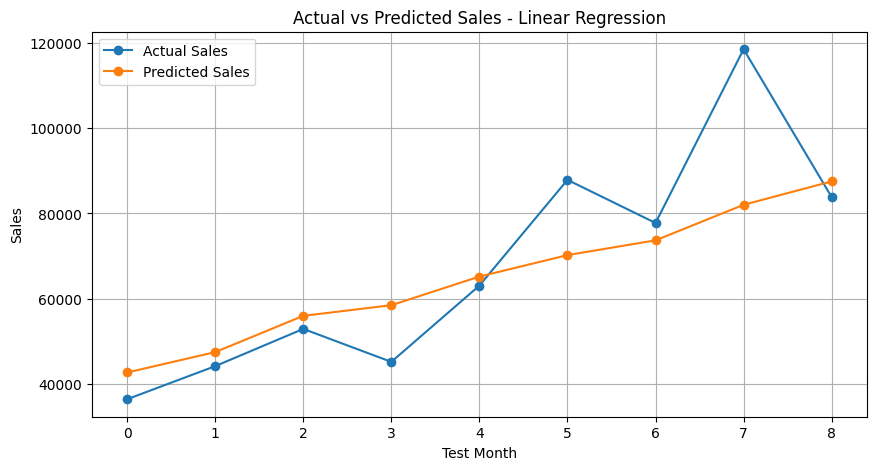

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values, marker='o', label='Actual Sales')
plt.plot(y_pred_lr, marker='o', label='Predicted Sales')

plt.title('Actual vs Predicted Sales - Linear Regression')
plt.xlabel('Test Month')
plt.ylabel('Sales')

plt.legend()
plt.grid(True)

plt.show()

# **Step 24 — Let's try Model 2: Random Forest**

In [30]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [31]:
model_rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [32]:
y_pred_rf = model_rf.predict(X_test)

y_pred_rf

array([40516.0971885, 43398.1886565, 38638.429948 , 39868.5800645,
       40616.0115815, 61839.361432 , 62729.8980025, 76815.2560115,
       83146.934384 ])

# **Step 25 — Evaluate Random Forest**

In [33]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE :", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²  :", r2_rf)

Random Forest MAE : 14498.97332311111
Random Forest RMSE: 19423.88296128374
Random Forest R²  : 0.39430512785921945


# **Step 26**

# **26A — Add rolling features**

In [34]:
forecast_df['Rolling_Mean_3'] = forecast_df['Sales'].shift(1).rolling(window=3).mean()
forecast_df['Rolling_Mean_6'] = forecast_df['Sales'].shift(1).rolling(window=6).mean()

forecast_df.head(10)

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Month,Year,Rolling_Mean_3,Rolling_Mean_6
0,2014-04,28295.3450,55691.0090,4519.8920,14236.8950,4,2014,NaN,NaN
1,2014-05,23648.2870,28295.3450,55691.0090,4519.8920,5,2014,NaN,NaN
2,2014-06,34595.1276,23648.2870,28295.3450,55691.0090,6,2014,NaN,NaN
3,2014-07,33946.3930,34595.1276,23648.2870,28295.3450,7,2014,28846.253200,NaN
4,2014-08,27909.4685,33946.3930,34595.1276,23648.2870,8,2014,30729.935867,NaN
5,2014-09,81777.3508,27909.4685,33946.3930,34595.1276,9,2014,32150.329700,NaN
6,2014-10,31453.3930,81777.3508,27909.4685,33946.3930,10,2014,47877.737433,38361.995317
7,2014-11,78628.7167,31453.3930,81777.3508,27909.4685,11,2014,47046.737433,38888.336650
8,2014-12,69545.6205,78628.7167,31453.3930,81777.3508,12,2014,63953.153500,48051.741600
9,2015-01,18174.0756,69545.6205,78628.7167,31453.3930,1,2015,59875.910067,53876.823750


# **Step 27 — Rebuild our forecasting dataset**

In [35]:
forecast_df = forecast_df.dropna().reset_index(drop=True)

print("Rows remaining:", len(forecast_df))
forecast_df.head()

Rows remaining: 39


,Order Date,Sales,Lag_1,Lag_2,Lag_3,Month,Year,Rolling_Mean_3,Rolling_Mean_6
0,2014-10,31453.3930,81777.3508,27909.4685,33946.3930,10,2014,47877.737433,38361.995317
1,2014-11,78628.7167,31453.3930,81777.3508,27909.4685,11,2014,47046.737433,38888.336650
2,2014-12,69545.6205,78628.7167,31453.3930,81777.3508,12,2014,63953.153500,48051.741600
3,2015-01,18174.0756,69545.6205,78628.7167,31453.3930,1,2015,59875.910067,53876.823750
4,2015-02,11951.4110,18174.0756,69545.6205,78628.7167,2,2015,55449.470933,51248.104183


# **Step 28 — Check the new dataset**

In [36]:
forecast_df.shape

(39, 9)

In [37]:
forecast_df.isnull().sum()

,0
Order Date,0
Sales,0
Lag_1,0
Lag_2,0
Lag_3,0
Month,0
Year,0
Rolling_Mean_3,0
Rolling_Mean_6,0


# **Step 28 — Rebuild X and y**

In [38]:
X = forecast_df[
    [
        'Lag_1',
        'Lag_2',
        'Lag_3',
        'Month',
        'Year',
        'Rolling_Mean_3',
        'Rolling_Mean_6'
    ]
]

y = forecast_df['Sales']

# **Step 29 — Make the time-based train/test split again**

In [39]:
split_index = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 31
Testing rows: 8


# **Step 30 — Train the improved Linear Regression model**

**30A — Create the model**

In [40]:
model_lr2 = LinearRegression()

**30B — Train it**

In [41]:
model_lr2.fit(X_train, y_train)

LinearRegression()

**30C — Predict the 8 test months**

In [42]:
y_pred_lr2 = model_lr2.predict(X_test)

y_pred_lr2

array([ 63095.13297146,  53698.71418921,  49672.26762883,  57387.70362367,
        68922.00997087,  76263.41546039,  92635.45531121, 103253.73367037])

# **Step 31 — Evaluate Improved Linear Regression**

In [43]:
mae_lr2 = mean_absolute_error(y_test, y_pred_lr2)
rmse_lr2 = np.sqrt(mean_squared_error(y_test, y_pred_lr2))
r2_lr2 = r2_score(y_test, y_pred_lr2)

print("Improved Linear Regression MAE :", mae_lr2)
print("Improved Linear Regression RMSE:", rmse_lr2)
print("Improved Linear Regression R²  :", r2_lr2)

Improved Linear Regression MAE : 11923.372699216441
Improved Linear Regression RMSE: 15051.20233827243
Improved Linear Regression R²  : 0.5978433453641055


# **Step 32 — Create one common test period**

In [44]:
# Use the last 8 months as test data
split_index = len(forecast_df) - 8

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTest period:")
print(forecast_df.iloc[split_index:][['Order Date', 'Sales']])

Training rows: 31
Testing rows: 8

Test period:
   Order Date        Sales
31    2017-05   44261.1102
32    2017-06   52981.7257
33    2017-07   45264.4160
34    2017-08   63120.8880
35    2017-09   87866.6520
36    2017-10   77776.9232
37    2017-11  118447.8250
38    2017-12   83829.3188


# **Step 33 — Train Linear Regression again**

In [45]:
model_lr_final = LinearRegression()

model_lr_final.fit(X_train, y_train)

y_pred_lr_final = model_lr_final.predict(X_test)

# **Step 34 — Train Random Forest again**

In [46]:
model_rf_final = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_rf_final.fit(X_train, y_train)

y_pred_rf_final = model_rf_final.predict(X_test)

# **Step 35 — Calculate both models' scores**

In [47]:
results = []

# Linear Regression
results.append({
    'Model': 'Linear Regression',
    'MAE': mean_absolute_error(y_test, y_pred_lr_final),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr_final)),
    'R2': r2_score(y_test, y_pred_lr_final)
})

# Random Forest
results.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_test, y_pred_rf_final),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf_final)),
    'R2': r2_score(y_test, y_pred_rf_final)
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,11923.372699,15051.202338,0.597843
1,Random Forest,16495.838451,20751.673883,0.235532


# **Step 36 — See exactly where the model succeeds/fails**

In [48]:
final_comparison = pd.DataFrame({
    'Order Date': forecast_df.iloc[split_index:]['Order Date'].values,
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred_lr_final
})

final_comparison['Error'] = (
    final_comparison['Actual Sales']
    - final_comparison['Predicted Sales']
)

final_comparison['Absolute Error'] = (
    final_comparison['Error'].abs()
)

final_comparison

,Order Date,Actual Sales,Predicted Sales,Error,Absolute Error
0,2017-05,44261.1102,63095.132971,-18834.022771,18834.022771
1,2017-06,52981.7257,53698.714189,-716.988489,716.988489
2,2017-07,45264.4160,49672.267629,-4407.851629,4407.851629
3,2017-08,63120.8880,57387.703624,5733.184376,5733.184376
4,2017-09,87866.6520,68922.009971,18944.642029,18944.642029
5,2017-10,77776.9232,76263.415460,1513.507740,1513.507740
6,2017-11,118447.8250,92635.455311,25812.369689,25812.369689
7,2017-12,83829.3188,103253.733670,-19424.414870,19424.414870


# **Step 37 — Actual vs Predicted graph for the final model**

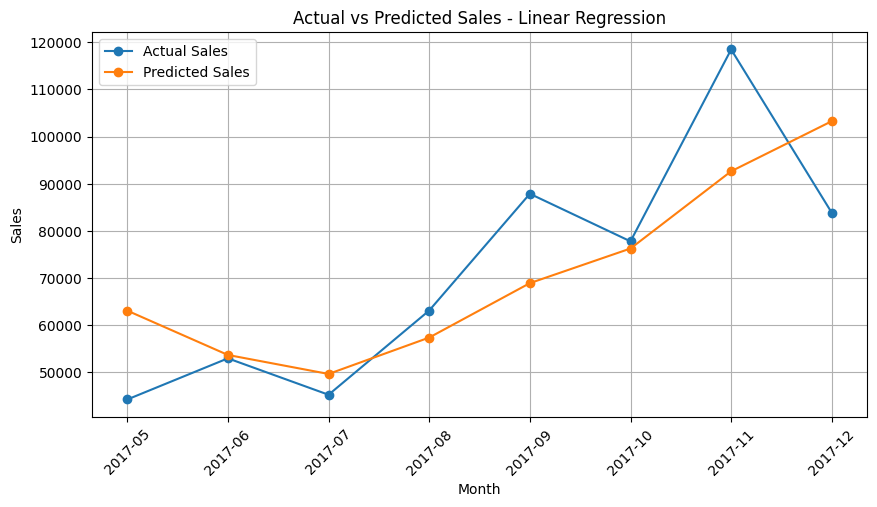

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(
    final_comparison['Order Date'].astype(str),
    final_comparison['Actual Sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    final_comparison['Order Date'].astype(str),
    final_comparison['Predicted Sales'],
    marker='o',
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales - Linear Regression')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

# **Step 42 — Create future dates**

In [50]:
future_dates = pd.date_range(
    start='2018-01-01',
    periods=6,
    freq='MS'
)

future_dates

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01'],
              dtype='datetime64[ns]', freq='MS')

# **Step 43 — Create the future forecasting table**

In [51]:
future_df = pd.DataFrame({
    'Order Date': future_dates
})

future_df['Month'] = future_df['Order Date'].dt.month
future_df['Year'] = future_df['Order Date'].dt.year

future_df


,Order Date,Month,Year
0,2018-01-01,1,2018
1,2018-02-01,2,2018
2,2018-03-01,3,2018
3,2018-04-01,4,2018
4,2018-05-01,5,2018
5,2018-06-01,6,2018


# **Step 45 — Let's calculate these automatically**

In [52]:
historical_sales = forecast_df['Sales'].tolist()

historical_sales[-10:]

[58872.3528,
 36521.5361,
 44261.1102,
 52981.7257,
 45264.416,
 63120.888,
 87866.652,
 77776.9232,
 118447.825,
 83829.3188]

# **Step 46 — Make the January 2018 feature row**

In [53]:
jan_features = pd.DataFrame({
    'Lag_1': [historical_sales[-1]],
    'Lag_2': [historical_sales[-2]],
    'Lag_3': [historical_sales[-3]],
    'Month': [1],
    'Year': [2018],
    'Rolling_Mean_3': [np.mean(historical_sales[-3:])],
    'Rolling_Mean_6': [np.mean(historical_sales[-6:])]
})

jan_features

,Lag_1,Lag_2,Lag_3,Month,Year,Rolling_Mean_3,Rolling_Mean_6
0,83829.3188,118447.825,77776.9232,1,2018,93351.355667,79384.337167


In [54]:
model_lr_final

LinearRegression()

# **Step 47 — Predict January 2018**

In [55]:
jan_prediction = model_lr_final.predict(jan_features)

jan_prediction

array([49782.94090898])

# **Step 48 — Forecast January → June automatically**

In [56]:
future_predictions = []

# Copy historical sales so we can add predictions one by one
sales_history = historical_sales.copy()

for date in future_dates:

    features = pd.DataFrame({
        'Lag_1': [sales_history[-1]],
        'Lag_2': [sales_history[-2]],
        'Lag_3': [sales_history[-3]],
        'Month': [date.month],
        'Year': [date.year],
        'Rolling_Mean_3': [np.mean(sales_history[-3:])],
        'Rolling_Mean_6': [np.mean(sales_history[-6:])]
    })

    prediction = model_lr_final.predict(features)[0]

    future_predictions.append(prediction)

    # Add the prediction so the next month can use it
    sales_history.append(prediction)

future_forecast = pd.DataFrame({
    'Order Date': future_dates,
    'Forecasted Sales': future_predictions
})

future_forecast

,Order Date,Forecasted Sales
0,2018-01-01,49782.940909
1,2018-02-01,62903.326082
2,2018-03-01,72588.375105
3,2018-04-01,77184.694188
4,2018-05-01,79982.000682
5,2018-06-01,74352.549297


# **Step 49 — Create the final Forecast Graph**

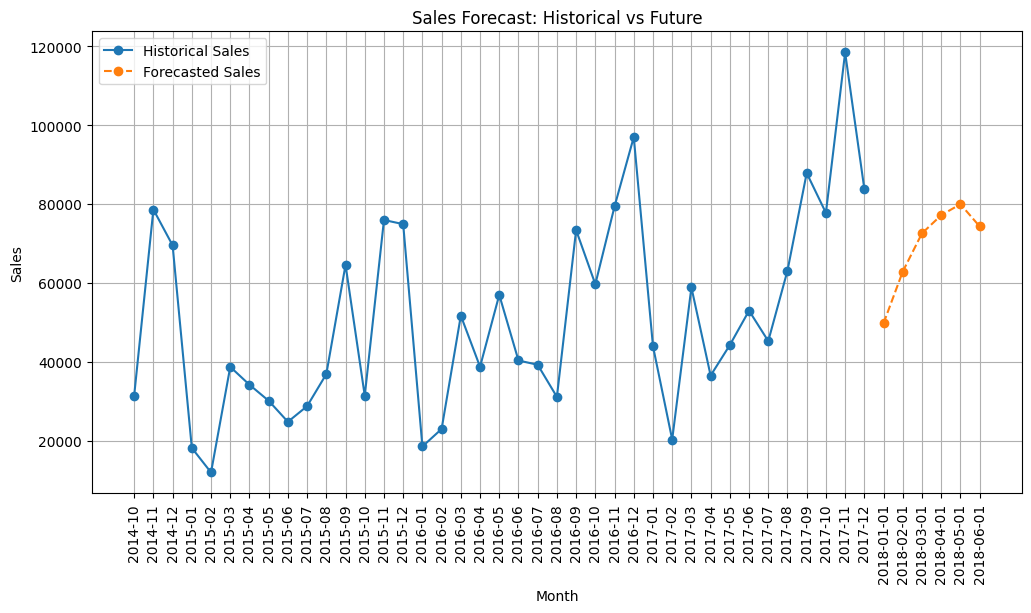

In [57]:
plt.figure(figsize=(12, 6))

plt.plot(
    forecast_df['Order Date'].astype(str),
    forecast_df['Sales'],
    marker='o',
    label='Historical Sales'
)

plt.plot(
    future_forecast['Order Date'].astype(str),
    future_forecast['Forecasted Sales'],
    marker='o',
    linestyle='--',
    label='Forecasted Sales'
)

plt.title('Sales Forecast: Historical vs Future')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=90)
plt.legend()
plt.grid(True)

plt.show()

In [58]:
future_forecast.to_csv('future_sales_forecast.csv', index=False)